# DX 704 Week 3 Project

This week's project will give you practice with optimizing choices for bandit algorithms.
You will be given access to the bandit problem via a blackbox object, and you will investigate the bandit rewards to pick a suitable algorithm.

The full project description, a template notebook and supporting code are available on GitHub: [Project 3 Materials](https://github.com/bu-cds-dx704/dx704-project-03).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

In [126]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

## Part 1: Pick a Bandit Algorithm

Experiment with the multi-armed bandit interface using seed 0 to learn about the distribution of rewards and decide what kind of bandit algorithm will be appropriate.
A histogram will likely be helpful.

In [127]:
# DO NOT CHANGE

import numpy as np

class BanditProblem(object):
    def __init__(self, seed):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.num_arms = 3
        self.ns = self.rng.integers(low=1, high=10, size=self.num_arms)
        self.ps = self.rng.uniform(low=0.2, high=0.4, size=self.num_arms)

    def get_num_arms(self):
        return self.num_arms

    def get_reward(self, arm):
        if arm < 0 or arm >= self.num_arms:
            raise ValueError("Invalid arm")

        x = self.rng.uniform()
        x *= self.rng.binomial(self.ns[arm], self.ps[arm])

        return x


In [128]:
bandit0 = BanditProblem(0)

In [129]:
bandit0.get_num_arms()

3

In [130]:
bandit0.get_reward(arm=0)

1.8255111545554434

In [131]:
rewards_arm0 = [bandit0.get_reward(arm=0) for _ in range(10_000)]
rewards_arm1 = [bandit0.get_reward(arm=1) for _ in range(10_000)]
rewards_arm2 = [bandit0.get_reward(arm=2) for _ in range(10_000)]

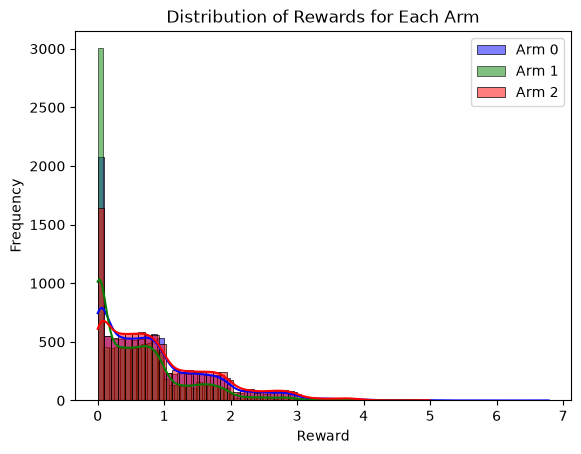

In [132]:
sns.histplot(rewards_arm0, color='blue', label='Arm 0', kde=True)
sns.histplot(rewards_arm1, color='green', label='Arm 1', kde=True)
sns.histplot(rewards_arm2, color='red', label='Arm 2', kde=True)
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.title('Distribution of Rewards for Each Arm')
plt.legend()
plt.show()

In [133]:
sum(rewards_arm0)

8352.156544165822

In [134]:
sum(rewards_arm2)

9091.513861241476

In [135]:
np.mean(rewards_arm0)

np.float64(0.8352156544165824)

In [136]:
np.mean(rewards_arm2)

np.float64(0.9091513861241476)

We can see Arm 1 has the lowest rewards

Comparing Arm 0 and 2, Arm 0 has a higher frequency of rewards around 0. Arm 0 has a lower frequency of rewards in the range of ~0.2 - 4. Arm 0 has a possibility of high rewards (5 - 6) which Arm 2 does not, though it is a very low count.

Based on these results, I would chose Arm 2 since it has more consistently high rewards than Arm 0

We need an algorithm which can identify that arm 2 has higher average rewards, even though arm 0 has a possibility of higher rewards

Based on your investigation, pick an appropriate bandit algorithm to implement from the algorithms covered this week.
Write a file "algorithm-choice.txt" that states your choice and give a single sentence justifying your choice and rejecting the alternatives.
Keep your explanation concise; you should be able to justify your choice solely based on the type of numbers observed, and whether those match the bandit algorithms that you have learned.

## Part 2: Implement Bandit

Based on your decision, implement an appropriate bandit algorithm and pick 1000 actions using seed 2026.

In [137]:
# YOUR CHANGES HERE

class EGreedy():
    def __init__(self, bandit, epsilon):
        """
        Bandit represents our BanditProblem instance
        epsilon is the probability of exploring (choosing a random arm)
        """
        self.bandit = bandit
        self.epsilon = epsilon
        self.num_arms = bandit.get_num_arms()
        self.counts = np.zeros(self.num_arms) # How many times arm is selected
        self.expected_values = np.zeros(self.num_arms) # Expected value for each arm

        # For output tracking
        self.actions = [] # What arm got picked
        self.rewards = [] # What reward was received

    def select_arm(self):
        # Coin flip with probability eps and 1-eps for exploration and exploitation respectively
        arm_choice = -1
        if np.random.rand() < self.epsilon:
            # Exploration: choose a random arm
            arm_choice = np.random.randint(self.num_arms)
        else:
            # Exploitation: choose the arm with the highest estimated value
            arm_choice = np.argmax(self.expected_values)

        self.actions.append(arm_choice)
        return arm_choice

    def update(self, arm, reward):
        self.rewards.append(reward)
        
        self.counts[arm] += 1
        n = self.counts[arm]

        # Before the arm was pulled, what was expected value? (n-1 pulls)
        old_expected_value = self.expected_values[arm]
        # After the arm was pulled, what is the new expected value? (n pulls)
        new_expected_value = ((n - 1) / n) * old_expected_value + (1 / n) * reward

        self.expected_values[arm] = new_expected_value

In [138]:
bandit = BanditProblem(seed=2026)

In [139]:
e_greedy_agent = EGreedy(bandit, epsilon=0.5) # Just picking a constant value for epsilon for now

In [140]:
for i in range(1000):
    arm = e_greedy_agent.select_arm()
    reward = bandit.get_reward(arm)
    e_greedy_agent.update(arm, reward)

Write a file "history.tsv" with columns action and reward in the order that the actions were taken.

In [141]:
# YOUR CHANGES HERE

history_df = pd.DataFrame({
    'action': e_greedy_agent.actions,
    'reward': e_greedy_agent.rewards
})
history_df

,action,reward
0,0,3.162073
1,0,0.532060
2,0,1.491514
3,0,2.759550
4,0,1.505464
...,...,...
995,0,2.185100
996,0,0.354824
997,0,2.502218
998,0,0.982299


array([[<Axes: title={'center': 'action'}>,
        <Axes: title={'center': 'reward'}>]], dtype=object)

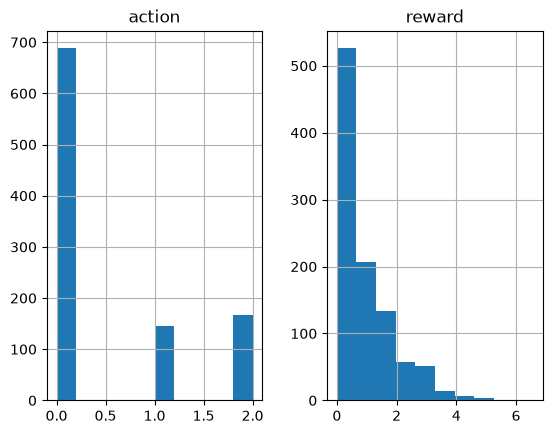

In [142]:
history_df.hist()

In [143]:
history_df.to_csv('history.tsv', sep='\t', index=False)

Submit "history.tsv" in Gradescope.

## Part 3: Action Statistics

Based on the data from part 2, estimate the expected reward for each arm and write a file "actions.tsv" with the columns action, min_reward, mean_reward, max_reward.

In [ ]:
min_rewards_per_arm = history_df.groupby('action')['reward'].min()
mean_rewards_per_arm = history_df.groupby('action')['reward'].mean()
max_rewards_per_arm = history_df.groupby('action')['reward'].max()

KeyError: 'arm'

In [ ]:
# YOUR CHANGES HERE

actions_df = pd.DataFrame({
    'action': [0,1,2],
    'min_reward': [min_rewards_per_arm[0], min_rewards_per_arm[1], min_rewards_per_arm[2]],
    'mean_reward': [mean_rewards_per_arm[0], mean_rewards_per_arm[1], mean_rewards_per_arm[2]],
    'max_reward': [max_rewards_per_arm[0], max_rewards_per_arm[1], max_rewards_per_arm[2]]
})
actions_df

,action,min_reward,mean_reward,max_reward
0,0,0.0,1.215880,6.564312
1,1,0.0,0.266348,1.755923
2,2,0.0,0.120175,0.999391


In [146]:
actions_df.to_csv('actions.tsv', sep='\t', index=False)

Submit "actions.tsv" in Gradescope.

## Part 4: Regret Estimates

Estimate the regret taking 1000 actions with the following strategies.

* uniform: Pick an arm uniformly at random.
* just-i: Always pick arm $i$. Do this for $i=0$ to $K-1$ where $K$ is the number of arms.
* actual: This should match your output in part 2.

These estimates should be based on your previous action statistics; you should not use the true action values from the bandit code.

In [ ]:
# Regret = the difference between the benchmark value after n time steps and the expected total reward of the agent after n time steps.

# Uniform: Sample randomly from actions_df and calculate regret
uniform_rewards = []
for _ in range(1000):
    arm = np.random.choice(actions_df['action'])
    reward = bandit.get_reward(arm)
    uniform_rewards.append(reward)
regret_uniform = sum(uniform_rewards) - sum(e_greedy_agent.rewards)
regret_uniform

-377.5918852408847

In [ ]:
# Just-i: Always pick arm i. Do this for i=0 to K-1
just_i_regrets = []
for i in range(bandit.get_num_arms()):
    just_i_rewards = []
    for _ in range(1000):
        reward = bandit.get_reward(i)
        just_i_rewards.append(reward)
    regret_just_i = sum(just_i_rewards) - sum(e_greedy_agent.rewards)
    just_i_regrets.append(regret_just_i)
just_i_regrets

[256.4550266152488, -590.3111717034917, -755.6091450799418]

In [ ]:
# Actual: Output from part 2
actual_regret = 0

In [ ]:
strategies_df = pd.DataFrame({
    'strategy': ['uniform', 'just-0', 'just-1', 'just-2', 'actual'],
    'regret': [regret_uniform, *just_i_regrets, actual_regret]
})
strategies_df

,strategy,regret
0,uniform,-377.591885
1,just-0,256.455027
2,just-1,-590.311172
3,just-2,-755.609145
4,actual,0.000000


Write your results to a file "strategies.tsv" with the columns strategy and regret.

In [ ]:
# YOUR CHANGES HERE

strategies_df.to_csv('strategies.tsv', sep='\t', index=False)

Submit "strategies.tsv" in Gradescope.

## Part 5: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


Submit "acknowledgments.txt" in Gradescope.

## Part 6: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.

Submit "project.ipynb" in Gradescope.